In [3]:
from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# !unzip /content/drive/MyDrive/idd-description-100.zip

In [5]:
import torch
import torch.nn as nn
import torchvision
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import math

In [6]:
import os

DATASET_ROOT = "/content/content/idd-description-100"
IMAGE_FOLDER = os.path.join(DATASET_ROOT, "images")
DESCRIPTION_FOLDER = os.path.join(DATASET_ROOT, "descriptions")

print("Images path:", IMAGE_FOLDER)
print("Descriptions path:", DESCRIPTION_FOLDER)

print("Number of images:", len(os.listdir(IMAGE_FOLDER)))
print("Number of descriptions:", len(os.listdir(DESCRIPTION_FOLDER)))

Images path: /content/content/idd-description-100/images
Descriptions path: /content/content/idd-description-100/descriptions
Number of images: 100
Number of descriptions: 100


In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # Resize image to 224x224
    transforms.ToTensor(),           # Convert image to tensor (0–1 range)
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]    # ImageNet std
    )
])

In [8]:
# Get one image filename
image_files = os.listdir(IMAGE_FOLDER)
print("Sample image file:", image_files[0])

# Full image path
sample_image_path = os.path.join(IMAGE_FOLDER, image_files[0])

# Load image
img = Image.open(sample_image_path).convert("RGB")

# Apply transform
img_tensor = transform(img)

# Add batch dimension
img_tensor = img_tensor.unsqueeze(0)

print("Tensor shape:", img_tensor.shape)

Sample image file: frame20980_image.jpg
Tensor shape: torch.Size([1, 3, 224, 224])


In [9]:
class CNNEncoder(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()

        # Load pretrained ResNet-50
        resnet = models.resnet50(pretrained=True)

        # Remove avgpool and fc layers
        modules = list(resnet.children())[:-2]
        self.backbone = nn.Sequential(*modules)

        # Freeze all layers first
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Unfreeze ONLY last block (layer4) for fine-tuning
        for param in self.backbone[-1].parameters():
            param.requires_grad = True

        # Projection layer to match decoder dimension
        self.projection = nn.Linear(2048, embed_dim)

    def forward(self, images):
        features = self.backbone(images)
        # Shape: (B, 2048, 7, 7)

        B, C, H, W = features.shape

        # Convert to sequence of 49 region tokens
        features = features.view(B, C, -1)       # (B, 2048, 49)
        features = features.permute(0, 2, 1)     # (B, 49, 2048)

        # Project to embedding dimension
        features = self.projection(features)     # (B, 49, embed_dim)

        return features

In [10]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create encoder
encoder = CNNEncoder(embed_dim=512).to(device)

# Move image tensor to device
img_tensor = img_tensor.to(device)

# Forward pass
with torch.no_grad():
    features = encoder(img_tensor)

print("Output feature shape:", features.shape)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 203MB/s]


Output feature shape: torch.Size([1, 49, 512])


In [11]:
for name, param in encoder.named_parameters():
    if param.requires_grad:
        print(name)

backbone.7.0.conv1.weight
backbone.7.0.bn1.weight
backbone.7.0.bn1.bias
backbone.7.0.conv2.weight
backbone.7.0.bn2.weight
backbone.7.0.bn2.bias
backbone.7.0.conv3.weight
backbone.7.0.bn3.weight
backbone.7.0.bn3.bias
backbone.7.0.downsample.0.weight
backbone.7.0.downsample.1.weight
backbone.7.0.downsample.1.bias
backbone.7.1.conv1.weight
backbone.7.1.bn1.weight
backbone.7.1.bn1.bias
backbone.7.1.conv2.weight
backbone.7.1.bn2.weight
backbone.7.1.bn2.bias
backbone.7.1.conv3.weight
backbone.7.1.bn3.weight
backbone.7.1.bn3.bias
backbone.7.2.conv1.weight
backbone.7.2.bn1.weight
backbone.7.2.bn1.bias
backbone.7.2.conv2.weight
backbone.7.2.bn2.weight
backbone.7.2.bn2.bias
backbone.7.2.conv3.weight
backbone.7.2.bn3.weight
backbone.7.2.bn3.bias
projection.weight
projection.bias


In [12]:
import json

# Get one description file
desc_files = os.listdir(DESCRIPTION_FOLDER)
print("Sample description file:", desc_files[0])

sample_desc_path = os.path.join(DESCRIPTION_FOLDER, desc_files[0])

with open(sample_desc_path, "r") as f:
    data = json.load(f)

print("\nKeys in description:", data.keys())

print("\nTraffic_Flow sample:\n")
print(data["Traffic_Flow"][:300])

Sample description file: frame17135_image.txt

Keys in description: dict_keys(['Traffic_Flow', 'Road_Layout', 'Navigation_Clues', 'Safe_Stop_Zone'])

Traffic_Flow sample:

The image shows a road with a rocky wall on one side and a building on the other. There are no visible vehicles or traffic, and the road appears to be clear and unobstructed. The overall flow of traffic seems to be smooth and uncongested. Based on the image, it seems that you can maintain your speed


In [13]:
all_texts = []

for file in os.listdir(DESCRIPTION_FOLDER):
    path = os.path.join(DESCRIPTION_FOLDER, file)
    with open(path, "r") as f:
        data = json.load(f)

    # Collect all 4 fields
    all_texts.append(data["Traffic_Flow"])
    all_texts.append(data["Road_Layout"])
    all_texts.append(data["Navigation_Clues"])
    all_texts.append(data["Safe_Stop_Zone"])

print("Total text samples collected:", len(all_texts))
print("\nSample text:\n", all_texts[0][:200])

Total text samples collected: 400

Sample text:
 The image shows a road with a rocky wall on one side and a building on the other. There are no visible vehicles or traffic, and the road appears to be clear and unobstructed. The overall flow of traff


In [14]:
import re

def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)  # remove punctuation
    tokens = text.split()
    return tokens

# Test tokenizer
print(tokenize(all_texts[0])[:20])

['the', 'image', 'shows', 'a', 'road', 'with', 'a', 'rocky', 'wall', 'on', 'one', 'side', 'and', 'a', 'building', 'on', 'the', 'other', 'there', 'are']


In [15]:
from collections import Counter

# Count word frequency
word_counter = Counter()

for text in all_texts:
    tokens = tokenize(text)
    word_counter.update(tokens)

print("Total unique words:", len(word_counter))

Total unique words: 719


In [16]:
# Special tokens
PAD_TOKEN = "<PAD>"
START_TOKEN = "<START>"
END_TOKEN = "<END>"
UNK_TOKEN = "<UNK>"

vocab = [PAD_TOKEN, START_TOKEN, END_TOKEN, UNK_TOKEN]

# Add all words
vocab.extend(word_counter.keys())

# Create mappings
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

print("Final vocabulary size:", len(vocab))
print("\nExample mapping:")
print("the →", word2idx["the"])
print("Index 0 →", idx2word[0])

Final vocabulary size: 723

Example mapping:
the → 4
Index 0 → <PAD>


In [17]:
def text_to_sequence(text):
    tokens = tokenize(text)

    sequence = [word2idx[START_TOKEN]]

    for token in tokens:
        if token in word2idx:
            sequence.append(word2idx[token])
        else:
            sequence.append(word2idx[UNK_TOKEN])

    sequence.append(word2idx[END_TOKEN])

    return sequence

# Test
sample_seq = text_to_sequence(all_texts[0])
print("First 20 indices:", sample_seq[:20])

First 20 indices: [1, 4, 5, 6, 7, 8, 9, 7, 10, 11, 12, 13, 14, 15, 7, 16, 12, 4, 17, 18]


In [18]:
max_len = 0

for text in all_texts:
    seq = text_to_sequence(text)
    if len(seq) > max_len:
        max_len = len(seq)

print("Maximum sequence length:", max_len)

Maximum sequence length: 130


In [19]:
MAX_LEN = 130

def pad_sequence(seq, max_len=MAX_LEN):
    if len(seq) < max_len:
        seq = seq + [word2idx[PAD_TOKEN]] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq

# Test padding
padded = pad_sequence(sample_seq)
print("Length after padding:", len(padded))
print("Last 10 values:", padded[-10:])

Length after padding: 130
Last 10 values: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [20]:
from torch.utils.data import Dataset

class IDDSceneDataset(Dataset):
    def __init__(self, image_folder, description_folder, transform):
        self.image_folder = image_folder
        self.description_folder = description_folder
        self.transform = transform

        self.image_files = sorted(os.listdir(image_folder))
        self.description_files = sorted(os.listdir(description_folder))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Load image
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_folder, img_name)
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        # Load description
        desc_name = self.description_files[idx]
        desc_path = os.path.join(self.description_folder, desc_name)

        with open(desc_path, "r") as f:
            data = json.load(f)

        traffic_seq = pad_sequence(text_to_sequence(data["Traffic_Flow"]))
        road_seq = pad_sequence(text_to_sequence(data["Road_Layout"]))
        nav_seq = pad_sequence(text_to_sequence(data["Navigation_Clues"]))
        safe_seq = pad_sequence(text_to_sequence(data["Safe_Stop_Zone"]))

        return {
            "image": image,
            "traffic": torch.tensor(traffic_seq),
            "road": torch.tensor(road_seq),
            "nav": torch.tensor(nav_seq),
            "safe": torch.tensor(safe_seq)
        }

In [21]:
# Create dataset object
dataset = IDDSceneDataset(
    IMAGE_FOLDER,
    DESCRIPTION_FOLDER,
    transform
)

print("Dataset size:", len(dataset))

# Get one sample
sample = dataset[0]

print("\nImage shape:", sample["image"].shape)
print("Traffic shape:", sample["traffic"].shape)
print("Road shape:", sample["road"].shape)
print("Nav shape:", sample["nav"].shape)
print("Safe shape:", sample["safe"].shape)

Dataset size: 100

Image shape: torch.Size([3, 224, 224])
Traffic shape: torch.Size([130])
Road shape: torch.Size([130])
Nav shape: torch.Size([130])
Safe shape: torch.Size([130])


In [22]:
from torch.utils.data import DataLoader

batch_size = 4

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

# Test one batch
batch = next(iter(dataloader))

print("Batch image shape:", batch["image"].shape)
print("Batch traffic shape:", batch["traffic"].shape)

Batch image shape: torch.Size([4, 3, 224, 224])
Batch traffic shape: torch.Size([4, 130])


In [23]:
# Move encoder to device
encoder = CNNEncoder(embed_dim=512).to(device)

# Get one batch
batch = next(iter(dataloader))
images = batch["image"].to(device)

# Forward pass
with torch.no_grad():
    features = encoder(images)

print("Batch feature shape:", features.shape)

Batch feature shape: torch.Size([4, 49, 512])


In [24]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len=500):
        super().__init__()

        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, embed_dim, 2) * (-math.log(10000.0) / embed_dim)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return x

In [25]:
class TrafficDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=512, num_heads=8, num_layers=3):
        super().__init__()

        # Word embedding
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # Positional encoding
        self.pos_encoding = PositionalEncoding(embed_dim)

        # Transformer decoder layer
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            batch_first=True
        )

        # Stack multiple decoder layers
        self.transformer_decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=num_layers
        )

        # Final linear layer → vocabulary
        self.fc_out = nn.Linear(embed_dim, vocab_size)

    def forward(self, tgt_tokens, memory, tgt_mask=None):

        # Convert token indices to embeddings
        tgt = self.embedding(tgt_tokens)

        # Add positional encoding
        tgt = self.pos_encoding(tgt)

        # Transformer decoding
        output = self.transformer_decoder(
            tgt=tgt,
            memory=memory,
            tgt_mask=tgt_mask
        )

        # Convert to vocabulary logits
        logits = self.fc_out(output)

        return logits

In [26]:
# Create decoder
traffic_decoder = TrafficDecoder(vocab_size=len(vocab)).to(device)

# Get one batch
batch = next(iter(dataloader))

images = batch["image"].to(device)
traffic_tokens = batch["traffic"].to(device)

# Forward through CNN
with torch.no_grad():
    memory = encoder(images)   # (B, 49, 512)

# Create causal mask
def generate_square_subsequent_mask(sz):
    return torch.triu(torch.ones(sz, sz) * float('-inf'), diagonal=1)

seq_len = traffic_tokens.size(1)
tgt_mask = generate_square_subsequent_mask(seq_len).to(device)

# Forward through decoder
with torch.no_grad():
    logits = traffic_decoder(
        tgt_tokens=traffic_tokens,
        memory=memory,
        tgt_mask=tgt_mask
    )

print("Decoder output shape:", logits.shape)

Decoder output shape: torch.Size([4, 130, 723])


In [27]:
# Get one batch again
batch = next(iter(dataloader))

traffic_tokens = batch["traffic"].to(device)

# Shift tokens
input_tokens = traffic_tokens[:, :-1]   # remove last token
target_tokens = traffic_tokens[:, 1:]   # remove first token

print("Original shape:", traffic_tokens.shape)
print("Input shape:", input_tokens.shape)
print("Target shape:", target_tokens.shape)

Original shape: torch.Size([4, 130])
Input shape: torch.Size([4, 129])
Target shape: torch.Size([4, 129])


In [28]:
# Forward through CNN
memory = encoder(images)

# Create causal mask for new sequence length (129)
seq_len = input_tokens.size(1)
tgt_mask = generate_square_subsequent_mask(seq_len).to(device)

# Forward through decoder with shifted input
logits = traffic_decoder(
    tgt_tokens=input_tokens,
    memory=memory,
    tgt_mask=tgt_mask
)

print("Logits shape:", logits.shape)
print("Target shape:", target_tokens.shape)

Logits shape: torch.Size([4, 129, 723])
Target shape: torch.Size([4, 129])


In [29]:
criterion = nn.CrossEntropyLoss(ignore_index=word2idx["<PAD>"])

# Reshape logits and targets
logits_flat = logits.reshape(-1, len(vocab))      # (4*129, 723)
targets_flat = target_tokens.reshape(-1)          # (4*129)

print("Flattened logits shape:", logits_flat.shape)
print("Flattened targets shape:", targets_flat.shape)

# Compute loss
loss = criterion(logits_flat, targets_flat)

print("Loss value:", loss.item())

Flattened logits shape: torch.Size([516, 723])
Flattened targets shape: torch.Size([516])
Loss value: 6.638980388641357


In [30]:
optimizer = torch.optim.Adam([
    {"params": encoder.backbone[-1].parameters(), "lr": 1e-5},
    {"params": encoder.projection.parameters(), "lr": 1e-4},
    {"params": traffic_decoder.parameters(), "lr": 1e-4},
])

In [31]:
num_epochs = 5

encoder.train()
traffic_decoder.train()

for epoch in range(num_epochs):
    total_loss = 0

    for batch in dataloader:
        images = batch["image"].to(device)
        traffic_tokens = batch["traffic"].to(device)

        # Shift tokens
        input_tokens = traffic_tokens[:, :-1]
        target_tokens = traffic_tokens[:, 1:]

        # Forward pass
        memory = encoder(images)

        seq_len = input_tokens.size(1)
        tgt_mask = generate_square_subsequent_mask(seq_len).to(device)

        logits = traffic_decoder(
            tgt_tokens=input_tokens,
            memory=memory,
            tgt_mask=tgt_mask
        )

        # Compute loss
        logits_flat = logits.reshape(-1, len(vocab))
        targets_flat = target_tokens.reshape(-1)

        loss = criterion(logits_flat, targets_flat)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

Epoch [1/5] Loss: 4.8920
Epoch [2/5] Loss: 3.0493
Epoch [3/5] Loss: 2.3190
Epoch [4/5] Loss: 1.9741
Epoch [5/5] Loss: 1.7565


In [32]:
def generate_traffic_description(image_tensor, max_len=50):
    encoder.eval()
    traffic_decoder.eval()

    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        memory = encoder(image_tensor)

    # Start token
    generated_tokens = [word2idx["<START>"]]

    for _ in range(max_len):

        input_tokens = torch.tensor(generated_tokens).unsqueeze(0).to(device)

        tgt_mask = generate_square_subsequent_mask(
            input_tokens.size(1)
        ).to(device)

        with torch.no_grad():
            logits = traffic_decoder(
                tgt_tokens=input_tokens,
                memory=memory,
                tgt_mask=tgt_mask
            )

        # Get last token prediction
        next_token_logits = logits[:, -1, :]
        next_token = torch.argmax(next_token_logits, dim=-1).item()

        generated_tokens.append(next_token)

        if next_token == word2idx["<END>"]:
            break

    # Convert indices to words
    words = [idx2word[idx] for idx in generated_tokens]

    return " ".join(words)

In [33]:
# Take one sample from dataset
sample = dataset[0]

generated_text = generate_traffic_description(sample["image"])

print("Generated Traffic Description:\n")
print(generated_text)

Generated Traffic Description:

<START> the image shows a busy street with a mix of vehicles including cars motorcycles and a truck the traffic appears to be moving smoothly with no visible congestion the vehicles are spread out along the road and there are no obstructions or roadside objects that would impede the flow of


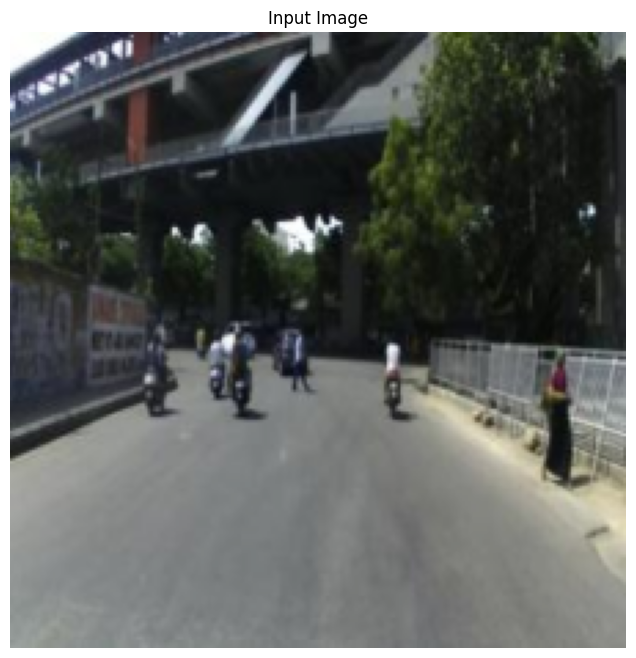

In [40]:
import matplotlib.pyplot as plt

# Get the first sample again
sample = dataset[7]
image_tensor = sample['image']

# Un-normalize the image for visualization
# Mean and std used: [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

vis_img = inv_normalize(image_tensor)
vis_img = vis_img.permute(1, 2, 0).numpy() # (C, H, W) -> (H, W, C)
vis_img = vis_img.clip(0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(vis_img)
plt.title("Input Image")
plt.axis('off')
plt.show()

In [35]:
class MultiTaskModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=512):
        super().__init__()

        # Shared CNN
        self.encoder = CNNEncoder(embed_dim=embed_dim)

        # 4 Decoders
        self.traffic_decoder = TrafficDecoder(vocab_size, embed_dim)
        self.road_decoder = TrafficDecoder(vocab_size, embed_dim)
        self.nav_decoder = TrafficDecoder(vocab_size, embed_dim)
        self.safe_decoder = TrafficDecoder(vocab_size, embed_dim)

    def forward(self, images,
                traffic_input,
                road_input,
                nav_input,
                safe_input,
                tgt_mask):

        memory = self.encoder(images)

        traffic_logits = self.traffic_decoder(traffic_input, memory, tgt_mask)
        road_logits = self.road_decoder(road_input, memory, tgt_mask)
        nav_logits = self.nav_decoder(nav_input, memory, tgt_mask)
        safe_logits = self.safe_decoder(safe_input, memory, tgt_mask)

        return traffic_logits, road_logits, nav_logits, safe_logits

In [36]:
multi_model = MultiTaskModel(vocab_size=len(vocab), embed_dim=512).to(device)


In [37]:
optimizer = torch.optim.Adam([
    # Fine-tune only layer4 of CNN
    {"params": multi_model.encoder.backbone[-1].parameters(), "lr": 1e-5},

    # Projection layer
    {"params": multi_model.encoder.projection.parameters(), "lr": 1e-4},

    # All four decoders
    {"params": multi_model.traffic_decoder.parameters(), "lr": 1e-4},
    {"params": multi_model.road_decoder.parameters(), "lr": 1e-4},
    {"params": multi_model.nav_decoder.parameters(), "lr": 1e-4},
    {"params": multi_model.safe_decoder.parameters(), "lr": 1e-4},
])

In [38]:
num_epochs = 5

multi_model.train()

for epoch in range(num_epochs):
    total_loss = 0

    for batch in dataloader:
        images = batch["image"].to(device)

        traffic_tokens = batch["traffic"].to(device)
        road_tokens = batch["road"].to(device)
        nav_tokens = batch["nav"].to(device)
        safe_tokens = batch["safe"].to(device)

        # Shift tokens for all tasks
        traffic_input = traffic_tokens[:, :-1]
        traffic_target = traffic_tokens[:, 1:]

        road_input = road_tokens[:, :-1]
        road_target = road_tokens[:, 1:]

        nav_input = nav_tokens[:, :-1]
        nav_target = nav_tokens[:, 1:]

        safe_input = safe_tokens[:, :-1]
        safe_target = safe_tokens[:, 1:]

        seq_len = traffic_input.size(1)
        tgt_mask = generate_square_subsequent_mask(seq_len).to(device)

        # Forward pass
        traffic_logits, road_logits, nav_logits, safe_logits = multi_model(
            images,
            traffic_input,
            road_input,
            nav_input,
            safe_input,
            tgt_mask
        )

        # Compute losses
        loss_traffic = criterion(
            traffic_logits.reshape(-1, len(vocab)),
            traffic_target.reshape(-1)
        )

        loss_road = criterion(
            road_logits.reshape(-1, len(vocab)),
            road_target.reshape(-1)
        )

        loss_nav = criterion(
            nav_logits.reshape(-1, len(vocab)),
            nav_target.reshape(-1)
        )

        loss_safe = criterion(
            safe_logits.reshape(-1, len(vocab)),
            safe_target.reshape(-1)
        )

        loss = loss_traffic + loss_road + loss_nav + loss_safe

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

Epoch [1/5] Loss: 17.0133
Epoch [2/5] Loss: 9.8150
Epoch [3/5] Loss: 7.5750
Epoch [4/5] Loss: 6.3643
Epoch [5/5] Loss: 5.5943


In [41]:
multi_model.eval()

# Define the helper function for text generation within this cell
def generate_text_from_decoder(decoder, memory, max_len=50):
    decoder.eval() # Ensure the decoder is in evaluation mode

    # Start token
    generated_tokens = [word2idx["<START>"]]

    for _ in range(max_len):
        input_tokens = torch.tensor(generated_tokens).unsqueeze(0).to(device)

        # Generate mask
        # The generate_square_subsequent_mask function is defined globally, so it should be accessible
        tgt_mask = generate_square_subsequent_mask(
            input_tokens.size(1)
        ).to(device)

        with torch.no_grad():
            logits = decoder(
                tgt_tokens=input_tokens,
                memory=memory,
                tgt_mask=tgt_mask
            )

        # Get last token prediction
        next_token_logits = logits[:, -1, :]
        next_token = torch.argmax(next_token_logits, dim=-1).item()

        generated_tokens.append(next_token)

        if next_token == word2idx["<END>"]:
            break

    # Convert indices to words
    words = [idx2word[idx] for idx in generated_tokens]

    return " ".join(words)


# Take one sample
sample = dataset[0]
image_tensor = sample["image"].unsqueeze(0).to(device)

with torch.no_grad():
    memory = multi_model.encoder(image_tensor)

traffic_text = generate_text_from_decoder(
    multi_model.traffic_decoder, memory
)

road_text = generate_text_from_decoder(
    multi_model.road_decoder, memory
)

nav_text = generate_text_from_decoder(
    multi_model.nav_decoder, memory
)

safe_text = generate_text_from_decoder(
    multi_model.safe_decoder, memory
)

print("=== Traffic Flow ===")
print(traffic_text)

print("\n=== Road Layout ===")
print(road_text)

print("\n=== Navigation Clues ===")
print(nav_text)

print("\n=== Safe Stop Zone ===")
print(safe_text)

=== Traffic Flow ===
<START> the image shows a busy street with a mix of vehicles including cars and a truck the traffic appears to be moving smoothly with no visible congestion the vehicles are spread out along the road and there are no obstructions or roadside objects that would impede the flow of traffic

=== Road Layout ===
<START> the road ahead appears to be a straight road with no visible curves or intersections it seems to be a clear path for the vehicles and pedestrians <END>

=== Navigation Clues ===
<START> in the image there are no visible signs indicating one way no entry or directional signs the scene shows a road with a road with a few vehicles including cars and a few pedestrians the road appears to be a twoway street and there are no signs that would restrict

=== Safe Stop Zone ===
<START> the image shows a busy street with multiple vehicles including cars and a motorcycle the road shoulders are not clearly visible but they appear to be narrow and possibly not suitabl